In [1]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [contractions] [anyascii]


In [27]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/davidsales/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/davidsales/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/davidsales/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [28]:
df = pd.read_csv("IMDB Dataset.csv")

In [6]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [8]:
def preprocess(text):
    text = re.sub(r'\\', '', text)
    text = contractions.fix(text)

    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[\d\W]+', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text)
    text = text.strip()

    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    tokens = [token for token in tokens if token not in stop_words]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = [t for t in tokens if len(t) >= 3]

    return " ".join(tokens)

In [9]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

'The accountant Shohei Sugiyama (Kôji Yakusho) is feeling bored with his routine life, limited to hard work and stay at home with his wife Masako Sugiyama (Hideko Hara) and his teenager\'s daughter. One night, while traveling home by train, he sees the beautiful face of Mai Kishikawa (Tamiyo Kusakari) in the balcony of a dance school, and a couple of days later, he decides to visit the school and secretly take ballroom dance lessons every Wednesdays night. However, he becomes ashamed to tell his family his secret. Meanwhile, Masako feels the changes in the behavior of her happier husband, and hires a private eye to investigate whether Shohei is having an affair.<br /><br />I have just finished watching "Shall We Dansu?" and I really loved it. What a lovely and delightful movie! The story is amazingly good, with drama, comedy and romance. The cast is excellent, and I was particularly impressed with the cold beauty and graciousness of the wife of the director Masayuki Suo and professiona

In [13]:
print(preprocess(df.iloc[random_num]['review']))

accountant shohei sugiyama kôji yakusho feeling bored routine life limited hard work stay home wife masako sugiyama hideko hara teenager daughter one night traveling home train see beautiful face mai kishikawa tamiyo kusakari balcony dance school couple day later decides visit school secretly take ballroom dance lesson every wednesday night however becomes ashamed tell family secret meanwhile masako feel change behavior happier husband hire private eye investigate whether shohei affair finished watching shall dansu really loved lovely delightful movie story amazingly good drama comedy romance cast excellent particularly impressed cold beauty graciousness wife director masayuki suo professional ballet dancer tamiyo kusakari last september saw american remake shall dansu first time found delightful entertainment say another unnecessary remake recommend original film instead vote ten title brazil dança comigo dance


In [14]:
df['review'] = df['review'].apply(preprocess)

In [15]:
df

,review,sentiment
0,one reviewer mentioned watching episode hooked...,positive
1,wonderful little production filming technique ...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically family little boy jake think zombie ...,negative
4,petter mattei love time money visually stunnin...,positive
...,...,...
49995,thought movie right good job creative original...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,catholic taught parochial elementary school nu...,negative
49998,going disagree previous comment side maltin on...,negative


In [16]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [18]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [19]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [20]:
max_len = 150

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [21]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=64))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add(Bidirectional(LSTM(64, return_sequences=True, dropout=0.3)))
lstm_model.add(Bidirectional(LSTM(32, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.summary()

2026-05-19 19:27:54.970885: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 150, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 150, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,389,377 (5.30 MB)

 Trainable params: 1,389,377 (5.30 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [23]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 92s 329ms/step - accuracy: 0.7512 - loss: 0.4865 - val_accuracy: 0.8765 - val_loss: 0.2975 - learning_rate: 5.0000e-04
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 332ms/step - accuracy: 0.9039 - loss: 0.2581 - val_accuracy: 0.8823 - val_loss: 0.2862 - learning_rate: 5.0000e-04
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 86s 346ms/step - accuracy: 0.9320 - loss: 0.1926 - val_accuracy: 0.8800 - val_loss: 0.2944 - learning_rate: 5.0000e-04


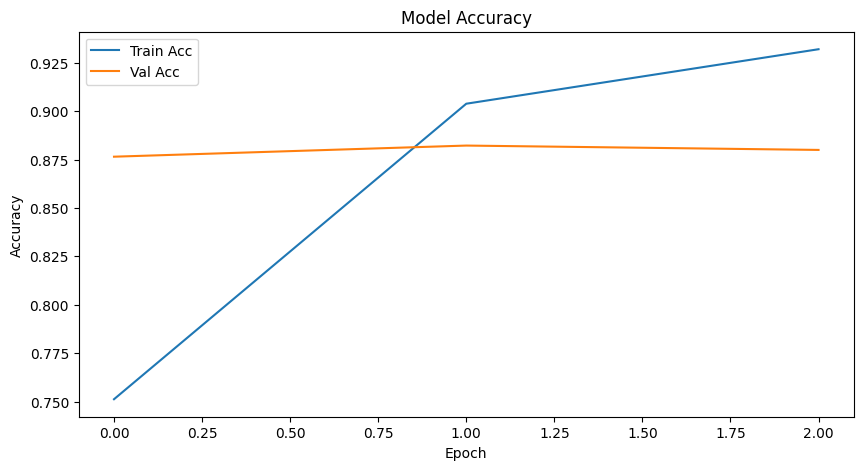

In [24]:
plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [25]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8854 - loss: 0.2724
Test Accuracy: 0.8853999972343445


## Confusion Matrices

In [34]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step


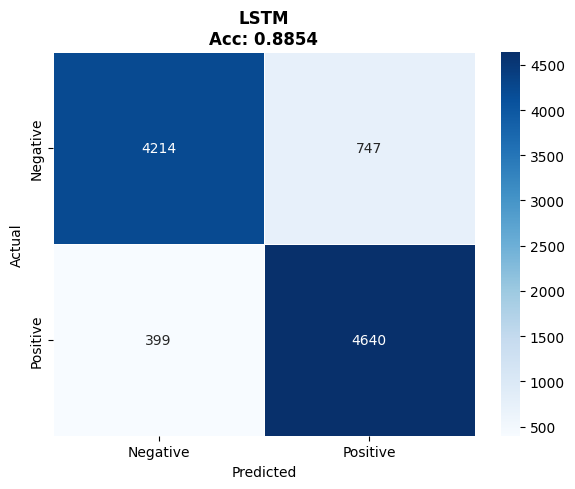

In [33]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

## Classification Reports

In [35]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.91      0.85      0.88      4961
    Positive       0.86      0.92      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [41]:
lstm_model.get_weights()

[array([[ 0.04269709,  0.04902335, -0.02348067, ..., -0.02941231,
          0.1292741 , -0.05785118],
        [ 0.00349773, -0.02484307,  0.01766269, ...,  0.01089414,
         -0.00741453, -0.02991714],
        [ 0.0273465 , -0.00976107,  0.02011556, ..., -0.00811977,
          0.0241077 , -0.00231713],
        ...,
        [ 0.0355156 , -0.01071671,  0.02238764, ...,  0.02036764,
         -0.01543055, -0.02602092],
        [-0.03815418,  0.03710999, -0.03063163, ...,  0.01201895,
          0.01300254, -0.04639984],
        [-0.00757763,  0.01717329, -0.02764539, ..., -0.00909615,
         -0.01226998, -0.00997112]], shape=(20000, 64), dtype=float32),
 array([[ 0.00698399, -0.13465819, -0.1403679 , ..., -0.01440572,
          0.1506242 ,  0.1088784 ],
        [-0.0355283 ,  0.06124527, -0.1393348 , ..., -0.0225204 ,
          0.05412634,  0.14288056],
        [ 0.00241764,  0.17135197, -0.0152113 , ...,  0.01296368,
         -0.07745998,  0.10816963],
        ...,
        [-0.02622316

In [42]:
sample = X_test_pad[0:1]

pred = lstm_model.predict(sample)

print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
[[0.03970314]]


In [43]:
from tensorflow.keras.models import Model

intermediate_model = Model(
    inputs=lstm_model.input,
    outputs=lstm_model.layers[0].output
)

lstm_output = intermediate_model.predict(sample)

print(lstm_output)
print(lstm_output.shape)

AttributeError: The layer sequential has never been called and thus has no defined input.